Title: Visualizations of Results and Comparisons Thereof
---

Author: Joe Holler  
Reproduction Materials Available at: [github.com/HEGSRR/RPr-Kang-2020](https://github.com/HEGSRR/RPr-Kang-2020)

Created: `15 Aug 2025`  
Revised: `15 Aug 2025`

In [177]:
# Import modules
import numpy as np
import pandas as pd
import geopandas as gpd
import re
from shapely.geometry import Point, LineString, Polygon
import matplotlib.pyplot as plt
from tqdm import tqdm
import folium
import itertools
import os
import time
import warnings
import requests
from scipy import stats
from IPython.display import display, clear_output

warnings.filterwarnings("ignore")
print('\n'.join(f'{m.__name__}=={m.__version__}' for m in globals().values() if getattr(m, '__version__', None)))

numpy==1.22.0
pandas==1.3.5
geopandas==0.10.2
networkx==2.6.3
osmnx==1.1.2
re==2.2.1
folium==0.12.1.post1
requests==2.27.1
ipywidgets==7.6.5


### Set working directory

Set the working directory to the root of the research compendium.

In [178]:
# if the working directory is the 'code' folder, move up two folders to the compendium root
if os.path.basename(os.getcwd()) == 'code':
    # This line moves the directory up two folders 
    os.chdir('../../')
print('The working directory is', os.getcwd())

The working directory is /home/jovyan/work/RPr-Kang-2020


In [179]:
import ipywidgets
from IPython.display import display

processor_dropdown = ipywidgets.Dropdown( options=[("1", 1), ("2", 2), ("3", 3), ("4", 4)],
    value=4, description="Processor: ")

population_dropdown = ipywidgets.Dropdown( options=[("Population at Risk", "pop"), ("COVID-19 Patients", "covid") ],
    value="pop", description="Population: ")

resource_dropdown = ipywidgets.Dropdown( options=[("ICU Beds", "icu_beds"), ("Ventilators", "vents") ],
    value="icu_beds", description="Resource: ")

display(processor_dropdown,population_dropdown,resource_dropdown)

Dropdown(description='Processor: ', index=3, options=(('1', 1), ('2', 2), ('3', 3), ('4', 4)), value=4)

Dropdown(description='Population: ', options=(('Population at Risk', 'pop'), ('COVID-19 Patients', 'covid')), …

Dropdown(description='Resource: ', options=(('ICU Beds', 'icu_beds'), ('Ventilators', 'vents')), value='icu_be…

### Study version parameters

Define the distance bands (minutes of driving time) and weights 

In [233]:
distances=[10, 20, 30] # Distances in travel time
weights=[1.0, 0.68, 0.22] # Weights where weights[0] is applied to distances[0]
buffered = True
print('distances: ', distances)
print('weights: ', weights)
print(population_dropdown.description, population_dropdown.value)
print(resource_dropdown.description, resource_dropdown.value, )
if buffered == True:
    buffertext = 'buffer'
else:
    buffertext = 'nobuffer'
print('buffered? ', buffertext)
versionname = buffertext + '_' + population_dropdown.value + '_' + resource_dropdown.value
print('version: ', versionname)

distances:  [10, 20, 30]
weights:  [1.0, 0.68, 0.22]
Population:  pop
Resource:  vents
buffered?  buffer
version:  buffer_pop_vents


In [234]:
# Load Results
if buffered:
    resultfile = 'data/derived/public/results_buffer.gpkg'
else:
    resultfile = 'data/derived/public/results_nobuffer.gpkg'
    
result = gpd.read_file(resultfile,
                       layer = '{}_{}'.format(population_dropdown.value,resource_dropdown.value))
result.head()

,id,ventsorig,vents,geometry
0,4158,0.001881,0.884099,"POLYGON ((440843.416 4638265.403, 440987.754 4..."
1,4159,0.001874,0.880636,"POLYGON ((440843.416 4637765.403, 440987.754 4..."
2,4156,0.001912,0.899111,"POLYGON ((440843.416 4639265.403, 440987.754 4..."
3,4157,0.001881,0.884099,"POLYGON ((440843.416 4638765.403, 440987.754 4..."
4,4154,0.001908,0.897030,"POLYGON ((440843.416 4640265.403, 440987.754 4..."


In [235]:
def output_map_classified(output_grid, hospitals, resource):
    ax=output_grid.plot(column=resource, 
                        scheme='Equal_Interval', 
                        k=5, 
                        linewidth=0,
                        cmap='Blues', 
                        figsize=(18,12), 
                        legend=True, 
                        label="Acc Measure",
                        zorder=1)
    # Next two lines set bounds for our x- and y-axes because it looks like there's a weird 
    # Point at the bottom left of the map that's messing up our frame (Maja)
    ax.set_xlim([325000, 370000])
    ax.set_ylim([550000, 600000])
    hospitals.plot(ax=ax, 
                   markersize=10, 
                   zorder=2,
                   c='black',
                   legend=False,
                   )

## Compare Reproduction with Original Results

Load results provided with the original research compendium from shapefile `data/derived/public/Chicago_ACC.shp`. The file contains fields `hospital_i` for "ICU Beds" and `hospital_v` for "Ventilators". It is not known exactly which version of code was used to create this set of results, although it appears that a more complete road network was used (probably the full state of Illinois) than was provided with the compendium (Chicago only, without a buffer). It is not known whether the population was population at risk (>50 years old) or COVID patients (cases). However, the statistical and geographic distributions of each are extremly similar once the data has been normalized.

In [236]:
# Import study results to compare
# hospital_i assumed to be for ICU and hospital_v assumed to be for ventilator
# however it's unknown whether the population is the COVID-19 population or the AT RISK population
fp = 'data/derived/public/Chicago_ACC.shp'
og_result = gpd.read_file(fp)
og_result.set_index("id")
og_result.head()

,id,hospital_i,hospital_v,geometry
0,4158,0.844249,0.843439,"POLYGON ((-87.71312 41.89411, -87.71140 41.896..."
1,4159,0.843600,0.843031,"POLYGON ((-87.71307 41.88961, -87.71135 41.891..."
2,4156,0.906094,0.904699,"POLYGON ((-87.71322 41.90312, -87.71150 41.905..."
3,4157,0.877197,0.876503,"POLYGON ((-87.71317 41.89861, -87.71145 41.900..."
4,4154,0.911424,0.910002,"POLYGON ((-87.71332 41.91212, -87.71160 41.914..."


### Join original results to current results

In [237]:
result.set_index("id")
result_compare = result.join(og_result[["hospital_i","hospital_v"]])
result_compare.head()

,id,ventsorig,vents,geometry,hospital_i,hospital_v
0,4158,0.001881,0.884099,"POLYGON ((440843.416 4638265.403, 440987.754 4...",0.844249,0.843439
1,4159,0.001874,0.880636,"POLYGON ((440843.416 4637765.403, 440987.754 4...",0.843600,0.843031
2,4156,0.001912,0.899111,"POLYGON ((440843.416 4639265.403, 440987.754 4...",0.906094,0.904699
3,4157,0.001881,0.884099,"POLYGON ((440843.416 4638765.403, 440987.754 4...",0.877197,0.876503
4,4154,0.001908,0.897030,"POLYGON ((440843.416 4640265.403, 440987.754 4...",0.911424,0.910002


### Calculate Spearman's Rank Correlation

In [238]:
# set original_resource variable to the name of original results column matching the modeling choice
if resource_dropdown.value == "icu_beds":
    original_resource = "hospital_i"
else:
    original_resource = "hospital_v"

# calculate spearman's rho
rho = stats.spearmanr(result_compare[[original_resource, resource_dropdown.value]])

# format text output
correlationmsg = "Comparing: \n" + "Original resource: " + resource_dropdown.value + " and population: unknown\n" + "Reproduction resource: " + resource_dropdown.value + " and population: " + population_dropdown.value
correlationmsg += "\nStreet network buffered? " + str(buffered)
print(correlationmsg)
rho_result = "Rho = " + str(round(rho.correlation,3)) + ", pvalue = " + str(round(rho.pvalue,3))
print(rho_result)

Comparing: 
Original resource: vents and population: unknown
Reproduction resource: vents and population: pop
Street network buffered? True
Rho = 0.97, pvalue = 0.0


### Create Scatterplot

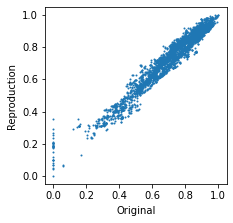

In [239]:
plt.figure(figsize=(3.25, 3.25))
plt.scatter(result_compare[[original_resource]], result_compare[[resource_dropdown.value]], s=1)
plt.xlabel("Original", labelpad=5)
plt.ylabel("Reproduction", labelpad=5)
#plt.text(.45, .08, rho_result, fontsize=8)
# save plot as image with file name including icu/ventilators and buffered or not
figpath = "./results/figures/reproduction/compare_" + versionname + ".png"
plt.savefig(figpath, dpi=600, bbox_inches='tight', facecolor='white')